## Template for calibration testing

- leakybucket
- 2years

In [97]:
# General python
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

# Niceties
# General eWaterCycle
# ensemble testing hydrostats etc
import hydrostats.metrics as hm
import matplotlib.pyplot as plt
import xarray as xr

In [98]:
leakybucker_dir = Path("../../model_runs/LeakyBucket/ensemble_test")

file_mmd = leakybucker_dir / "discharge_all_leakiness.nc"
file_m3s = leakybucker_dir / "discharge_m3s_leakiness.nc"

In [99]:
leakybucket_mmd = xr.open_dataset(file_mmd)
leakybucket_m3s = xr.open_dataset(file_m3s)

leakybucket_mmd_d = leakybucket_mmd.resample(time="1D").mean()
leakybucket_m3s_d = leakybucket_m3s.resample(time="1D").mean()

In [100]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(
    2617110,
    "1954-01-01T00:00Z",
    "1956-12-31T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

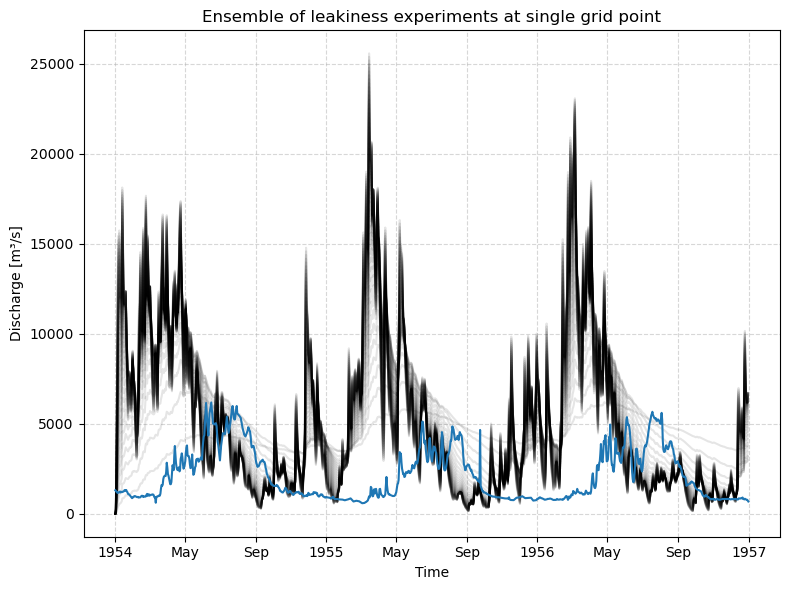

In [101]:
discharge_point_m3 = leakybucket_m3s_d.isel(latitude=0, longitude=0)

discharge_1955_m3 = discharge_point_m3.sel(time=slice("1954-01-01", "1956-12-31"))

discharge_selection = discharge_1955_m3.sel(leakiness=slice(0, 1))

plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_selection.leakiness.values):
    plt.plot(
        discharge_selection.time,
        discharge_selection["discharge"].isel(leakiness=i),
        label=f"leakiness={leak:.2f}",
        color="black",
        alpha=0.1,
    )


# plot GRDC
max_y = 2 * ds["streamflow"].max()
ds["streamflow"].plot()

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of leakiness experiments at single grid point")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [103]:
obs = ds["streamflow"]

obs_sel = obs.sel(time=slice(discharge_selection.time.min(), discharge_selection.time.max()))


leak_values = []
nse_values = []
kge_values = []
mle_values = []

for i, leak in enumerate(discharge_selection.leakiness.values):
    sim = discharge_selection["discharge"].isel(leakiness=i)

    # calculate metrics
    nse_val = hm.nse_mod(sim, obs_sel)
    kge_val = hm.kge_2012(sim, obs_sel)
    mle_val = hm.mle(sim, obs_sel)

    # store metrics
    nse_values.append(nse_val)
    kge_values.append(kge_val)
    mle_values.append(mle_val)

    leak_values.append(leak)

<function matplotlib.pyplot.show(close=None, block=None)>

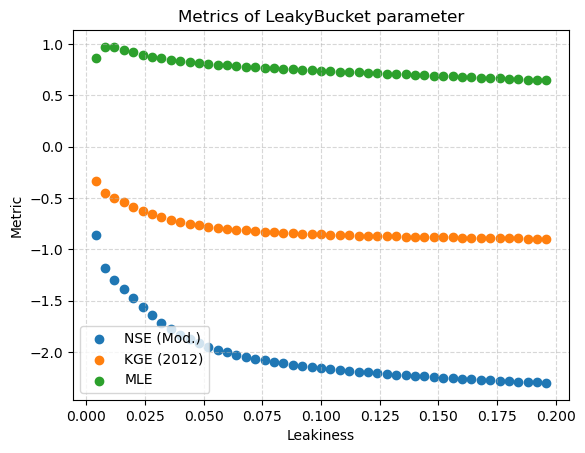

In [104]:
plt.scatter(leak_values, nse_values, label=hm.nse_mod.abbr)
plt.scatter(leak_values, kge_values, label=hm.kge_2012.abbr)
plt.scatter(leak_values, mle_values, label=hm.mle.abbr)
plt.xlabel("Leakiness")
plt.ylabel("Metric")
plt.grid(linestyle="--", alpha=0.5)
plt.legend()
plt.title("Metrics of LeakyBucket parameter")

plt.show